# SPOmiAlign Demo: Image to Image Section Alignment

This notebook follows a fixed workflow:
1. Input unaligned slices (paired images)
2. Imaging (generation of spatial structural images, SSI)
3. Sections matching and warpping
4. Reassignment
5. Output aligned slices

For PUCK29, SSI rendering keeps the rasterize-style coordinate handling.
No display-only translation or rescaling is applied during plotting.


## 1. Input unaligned slices (paired images)

In [1]:
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

NOTEBOOK_DIR = Path().resolve()
DEMO_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = DEMO_DIR.parent
sys.path.append(str(PROJECT_ROOT / "SPOmiAlign"))

from roma import align_and_process_images
from data_preprocessing import scatter_h5ad_to_image

DATA_DIR = Path(
    os.environ.get("SPOMIALIGN_DEMO_DATA_DIR", DEMO_DIR / "SPOmiAlign_Repro")
).expanduser()
SAVE_DIR = Path(
    os.environ.get("SPOMIALIGN_DEMO_SAVE_DIR", DEMO_DIR / "output")
).expanduser()
SAVE_PATH = SAVE_DIR / "h5ad_2_img/PUCK29"
SAVE_PATH.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {SAVE_PATH}")
h5ad_path = DATA_DIR / "data_preprocessing" / "Puck_Num_29.h5ad"
target_image_path = DATA_DIR / "output_reference" / "CCF_100048576_205.png"

assert h5ad_path.exists(), f"H5AD file not found: {h5ad_path}"
assert target_image_path.exists(), f"Target image not found: {target_image_path}"

target_img_for_shape = cv2.imread(str(target_image_path), cv2.IMREAD_COLOR)
assert target_img_for_shape is not None, f"Failed to read target image: {target_image_path}"
target_h, target_w = target_img_for_shape.shape[:2]

print(f"Input H5AD: {h5ad_path}")
print(f"Target image: {target_image_path}")
print(f"Target image size: {target_w} x {target_h}")


Data directory: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro
Output directory: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK29
Input H5AD: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/data_preprocessing/Puck_Num_29.h5ad
Target image: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_reference/CCF_100048576_205.png
Target image size: 5587 x 4183


## 2. Imaging (generation of spatial structural images, SSI)

[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK29/Gen_img_PUCK29_scatter.png (4787x5532, background=black, shape=circle, points=42664)


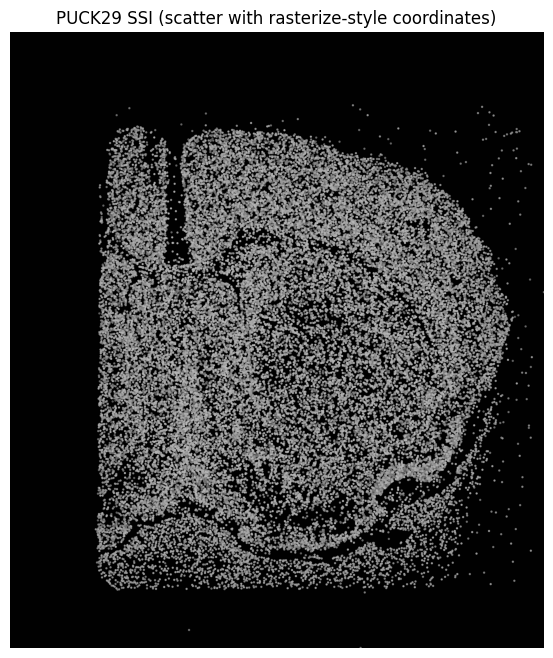

In [2]:
%matplotlib inline
Gen_img_path = SAVE_PATH / "Gen_img_PUCK29_scatter.png"

# Match rasterize_h5ad_to_image coordinate handling as closely as possible.
# Only the explicit rotate=180 transform is applied; no display_long_side scaling or padding shift.
_, origin = scatter_h5ad_to_image(
    input_h5ad=str(h5ad_path),
    output_png=str(Gen_img_path),
    x_obs_col="Raw_Slideseq_X",
    y_obs_col="Raw_Slideseq_Y",
    intensity_mode="obs_col",
    intensity_obs_col="nFeature_Spatial",
    intensity_log_transform=True,
    threshold_percentile=80,
    background="black",
    point_shape="circle",
    radius=5,
    rotate=180,
    scale=1.0,
    display_long_side=0,
    padding=0,
    dpi=130,
    marker_alpha=1.0,
    gray_min=0.55,
    gray_max=0.85,
    invert_intensity=False,
    enhance=True,
)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(cv2.imread(str(Gen_img_path)), cv2.COLOR_BGR2RGB))
plt.title("PUCK29 SSI (scatter with rasterize-style coordinates)")
plt.axis("off")
plt.show()


## 3. Sections matching and warpping

Using device: cuda:0


2026-04-13 00:12:02.607 | INFO     | romatch.models.model_zoo.roma_models:roma_model:61 - Using coarse resolution (560, 560), and upsample res (864, 1152)


Running RoMa matching...
Estimating affine+bspline transform...
Warping images...
Padding fill color: (255, 255, 255)
Processing H5AD coordinates...
Raw_Slideseq_X Raw_Slideseq_Y
[OK] Step 00 source coordinates mapped to render space: 213885/213885 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK29/alignment/debug_step_00_source_in_render_space.png
🔄 Applying manual pre-transform: rotate=180.0°, scale=1.0
[OK] Step 01 after manual pre-transform (source canvas): 213882/213885 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK29/alignment/debug_step_01_after_manual_pretransform.png
[OK] Step 02 after resize to registration grid (source resized canvas): 213880/213885 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK29/alignment/debug_step_02_after_resize_to_registration.png
[OK] Step 03 after registration transform (target resized canv

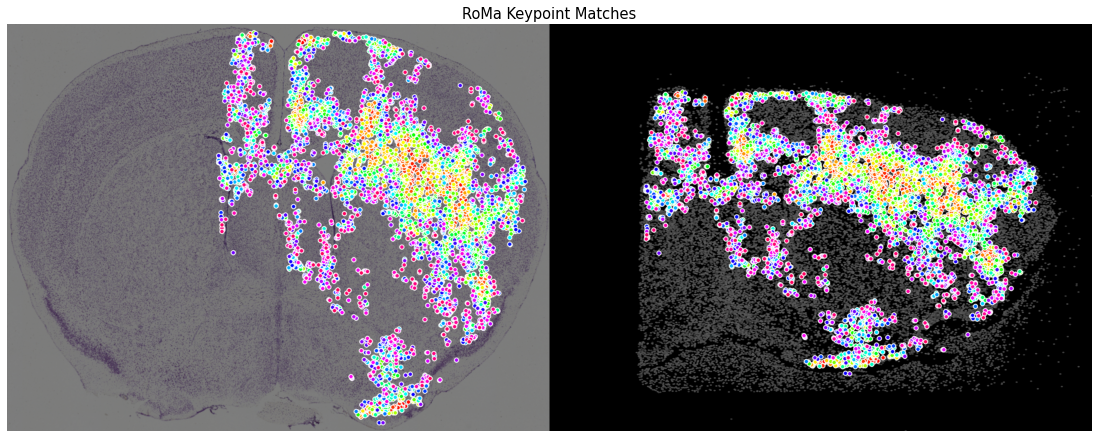

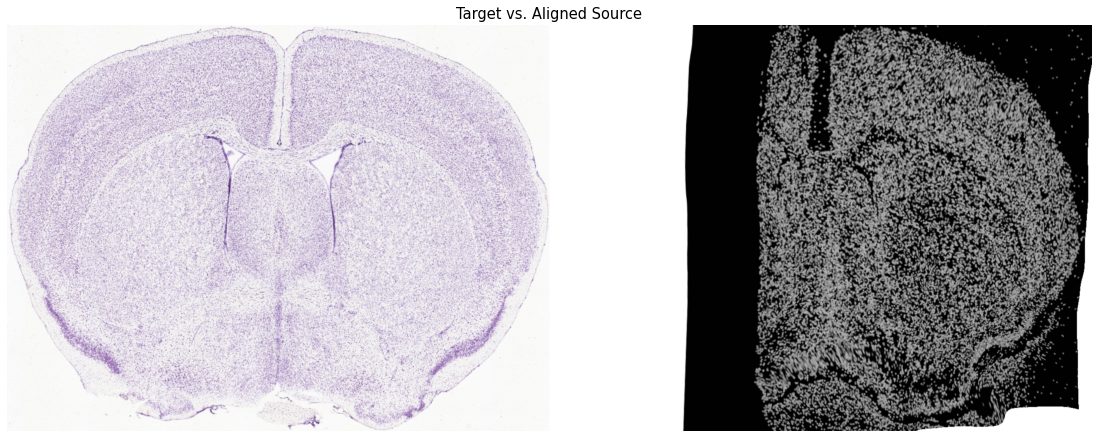

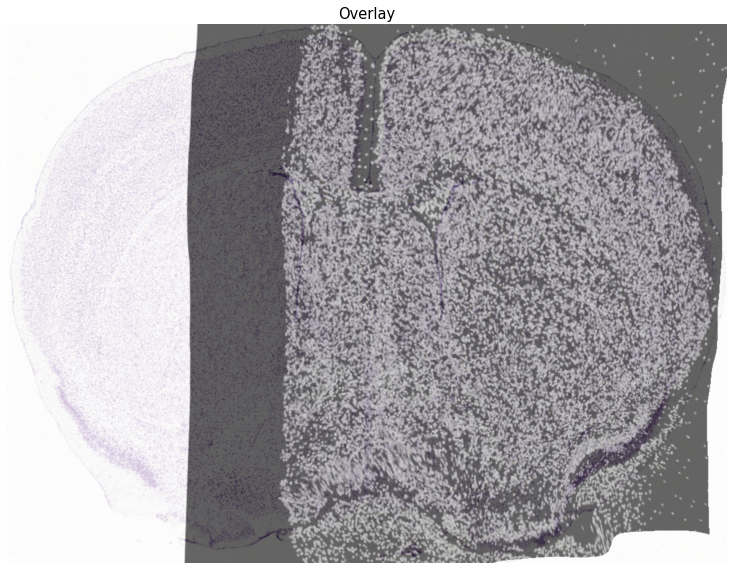

Alignment runtime: 28.1007 seconds
Done. Results saved to /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK29/alignment
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK29/alignment/transformed_h5ad_scatter.png (5587x4183, background=black, shape=circle, points=42664)


('/storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK29/alignment/transformed_h5ad_scatter.png',
 None)

In [3]:
save_path_alignment = SAVE_PATH / "alignment"
save_path_alignment.mkdir(parents=True, exist_ok=True)
transformed_h5ad_path = save_path_alignment / "transformed.h5ad"
transformed_h5ad_img_path = save_path_alignment / "transformed_h5ad_scatter.png"

align_and_process_images(
    img1_path=str(target_image_path),
    img2_path=str(Gen_img_path),
    h5ad_path=str(h5ad_path),
    method="affine+bspline",
    output_dir=str(save_path_alignment),
    x_obs_col="Raw_Slideseq_X",
    y_obs_col="Raw_Slideseq_Y",
    rotate=180.0,
    scale=1.0,
    origin=origin,
    auto_upscale_reference=False,
)

# Render transformed coordinates directly in the target image frame.
scatter_h5ad_to_image(
    input_h5ad=str(transformed_h5ad_path),
    output_png=str(transformed_h5ad_img_path),
    x_obs_col="Raw_Slideseq_X",
    y_obs_col="Raw_Slideseq_Y",
    intensity_mode="obs_col",
    intensity_obs_col="nFeature_Spatial",
    intensity_log_transform=True,
    threshold_percentile=80,
    background="black",
    point_shape="circle",
    radius=5,
    rotate=0,
    scale=1.0,
    display_long_side=0,
    padding=0,
    canvas_size=(target_w, target_h),
    dpi=150,
    marker_alpha=1.0,
    gray_min=0.55,
    gray_max=0.85,
    invert_intensity=False,
    enhance=True,
)


## 4. Reassignment

No reassignment step is used in this PUCK29 image-alignment demo.

## 5. Output aligned slices

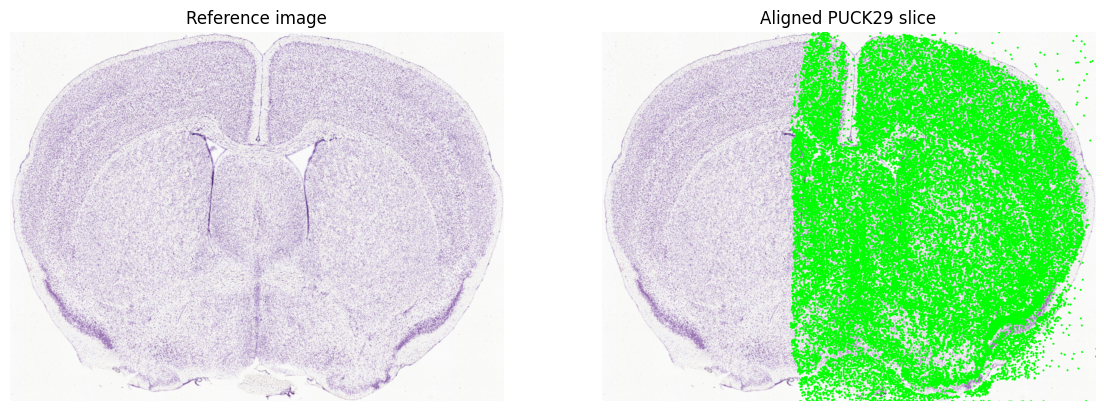

Aligned H5AD: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK29/alignment/transformed.h5ad
Overlay image: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK29/alignment/color_alignment_overlay.png


In [4]:
target_img = cv2.imread(str(target_image_path))
aligned_gray = cv2.imread(str(transformed_h5ad_img_path), cv2.IMREAD_GRAYSCALE)
assert target_img is not None, f"Failed to read target image: {target_image_path}"
assert aligned_gray is not None, f"Failed to read transformed SSI image: {transformed_h5ad_img_path}"

h5ad_mask_full = np.zeros(target_img.shape[:2], dtype=np.uint8)
h_limit = min(h5ad_mask_full.shape[0], aligned_gray.shape[0])
w_limit = min(h5ad_mask_full.shape[1], aligned_gray.shape[1])
h5ad_mask_full[:h_limit, :w_limit] = aligned_gray[:h_limit, :w_limit]

overlay_img = target_img.copy()
overlay_img[h5ad_mask_full > 50] = [0, 255, 0]
overlay_save_path = save_path_alignment / "color_alignment_overlay.png"
cv2.imwrite(str(overlay_save_path), overlay_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Reference image")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Aligned PUCK29 slice")
axes[1].axis("off")
plt.show()

print(f"Aligned H5AD: {transformed_h5ad_path}")
print(f"Overlay image: {overlay_save_path}")
